# BiLSTM 文本分类器（手写实现）

- **作者**：邓涵丹
- **日期**：2026-07-27
- **适用周次**：Week 4
- **分类**：NLP / PyTorch
- **关键词**：LSTM、双向LSTM、注意力池化、文本分类

## 学习目标

1. 使用 PyTorch 实现双向 LSTM 文本分类器。
2. 理解注意力池化如何从序列中提取关键信息。
3. 掌握数据预处理、训练循环和模型保存。

## 1. 背景与问题

RNN 及其变体（LSTM、GRU）是处理序列数据的经典模型。双向 LSTM 可以捕获上下文的双向依赖，结合注意力机制可以更好地关注重要信息。本 Notebook 将实现一个完整的 BiLSTM 分类器，用于 AG_NEWS 新闻标题的二分类任务。

In [1]:
import os
# 必须在导入 datasets 之前设置镜像
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import sys
import re
from collections import Counter

# 现在导入 datasets
from datasets import load_dataset

print(sys.version)
print("PyTorch version:", torch.__version__)

# 加载数据集
dataset = load_dataset("ag_news")
train_data = dataset["train"]
test_data = dataset["test"]
print(f"训练集大小: {len(train_data)}, 测试集大小: {len(test_data)}")

3.8.10 (default, Jun  4 2021, 15:09:15) 
[GCC 7.5.0]
PyTorch version: 1.13.0+cu117
训练集大小: 120000, 测试集大小: 7600


## 2. 数据准备

使用 torchtext 加载 AG_NEWS，将其转为二分类（前两类为正，后两类为负），并构建词汇表。

In [3]:
# ========== 自定义分词器 ==========
def simple_tokenizer(text):
    # 去除标点，保留字母和数字，转为小写
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text.lower().split()

# ========== 加载 AG_NEWS 数据集 ==========
dataset = load_dataset("ag_news")
train_data = dataset["train"]
test_data = dataset["test"]
print(f"训练集大小: {len(train_data)}, 测试集大小: {len(test_data)}")

# ========== 构建词汇表 ==========
def build_vocab(data_iter, min_freq=2):
    counter = Counter()
    for sample in data_iter:
        tokens = simple_tokenizer(sample["text"])
        counter.update(tokens)
    # 特殊标记
    vocab = {'<pad>': 0, '<unk>': 1}
    idx = 2
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1
    return vocab

vocab = build_vocab(train_data)
print(f"词汇表大小: {len(vocab)}")

# ========== 创建 PyTorch Dataset ==========
class AGNewsDataset(Dataset):
    def __init__(self, data, vocab, tokenizer, label_map=None):
        self.samples = []
        for item in data:
            text = item["text"]
            label = item["label"]
            if label_map is not None:
                label = label_map[label]
            tokens = [vocab.get(token, vocab['<unk>']) for token in tokenizer(text)]
            self.samples.append((torch.tensor(tokens, dtype=torch.long),
                                 torch.tensor(label, dtype=torch.long)))
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        return self.samples[idx]

# 标签映射：AG_NEWS 原始标签 1,2 -> 0；3,4 -> 1 (二分类)
label_map = {0:0, 1:0, 2:1, 3:1}

train_dataset = AGNewsDataset(train_data, vocab, simple_tokenizer, label_map)
test_dataset = AGNewsDataset(test_data, vocab, simple_tokenizer, label_map)

# ========== collate 函数（动态填充） ==========
def collate_batch(batch):
    texts, labels = zip(*batch)
    lengths = torch.tensor([len(t) for t in texts])
    # 按长度降序排序（为了 pack_padded_sequence）
    sorted_indices = torch.argsort(lengths, descending=True)
    texts = [texts[i] for i in sorted_indices]
    labels = torch.tensor([labels[i] for i in sorted_indices])
    lengths = lengths[sorted_indices]
    padded_texts = torch.nn.utils.rnn.pad_sequence(texts, batch_first=True, padding_value=vocab['<pad>'])
    return padded_texts, lengths, labels

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

训练集大小: 120000, 测试集大小: 7600
词汇表大小: 54864


## 2.1 变长序列处理深度解析（Pack & Pad）

在 NLP 中，一个批次（Batch）里的句子长度通常不一样。如果直接使用 `pad_sequence` 填充 0（或 `<pad>` 索引），LSTM 会把这些无意义的填充位也当作序列的一部分进行计算，这会导致两个严重问题：

1. **计算浪费**：LSTM 会遍历长达 `max_len` 的序列，即使某些样本只有 5 个有效词，计算量依然很大。
2. **语义污染**：虽然填充位对分类结果影响较小，但 LSTM 在读取填充位时依然会更新隐状态，这会稀释掉句子末尾的真实语义信息。

**PyTorch 的解决方案**：
- `pack_padded_sequence`：将变长序列“压缩”成 `PackedSequence` 数据类型。在压缩过程中，LSTM 只对有效长度内的词进行计算，一旦到达 `lengths[i]`，该序列就会从当前计算步骤中“退出”。
- `pad_packed_sequence`：将压缩后的数据还原成标准的 Tensor，方便后续的线性层处理。

**需要注意的细节**：
在 `collate_batch` 中按序列长度降序排序，是因为 LSTM 内部实现要求输入的序列长度必须是降序排列的，否则计算图会出错。

## 3. 模型定义（BiLSTM + 注意力池化）

In [4]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256,
                 num_layers=2, num_classes=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=vocab['<pad>'])
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        # 注意力权重计算
        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, lengths):
        # input_ids: (B, L), lengths: (B,)
        embedded = self.dropout(self.embedding(input_ids))  # (B, L, D)
        # 打包序列
        packed = torch.nn.utils.rnn.pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        output_packed, _ = self.lstm(packed)
        output, _ = torch.nn.utils.rnn.pad_packed_sequence(output_packed, batch_first=True)  # (B, L, 2H)
        # 注意力池化
        attn_weights = torch.softmax(self.attention(output), dim=1)  # (B, L, 1)
        context = (attn_weights * output).sum(dim=1)  # (B, 2H)
        return self.classifier(self.dropout(context))

## 3.1 为什么要用注意力池化，而不是取最后隐状态？

在传统的 RNN 分类任务中，常见做法是取 LSTM 最后一个时间步的输出（`output[:, -1, :]`）作为句子的表征。

**这种做法的缺陷**：
长序列中，最后一个词可能只是一个句号或者停用词，它无法代表整个句子的核心意图。实际上，判断一个句子的情感（正面/负面），通常依赖于若干个关键的情感词（如 "excellent"、"boring"）。

**注意力池化的核心思想**：
- 通过一个可学习的线性层 `self.attention = nn.Linear(2H, 1)` 来为**每一个**时间步打分。
- 这个分数的物理意义是：**“当前这个时间步（这个词）对于分类任务的重要程度”**。
- 通过 `Softmax` 将分数归一化为概率分布（权重和为 1）。
- 最后计算 **加权和（Weighted Sum）**：`context = Σ (权重 * 词向量)`。

这样，模型会自动学习并赋予情感强烈的词更高的权重，抑制无关词（如 "the", "is"）的影响，这比简单地取最后一个时间步或平均池化要更加灵敏和智能。

## 4. 训练与评估

定义训练循环，使用交叉熵损失和 Adam 优化器。

In [5]:
vocab_size = len(vocab)
model = BiLSTMClassifier(vocab_size)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for texts, lengths, labels in tqdm(loader, desc="Training"):
        texts, lengths, labels = texts.to(device), lengths.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(texts, lengths)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for texts, lengths, labels in tqdm(loader, desc="Evaluating"):
            texts, lengths, labels = texts.to(device), lengths.to(device), labels.to(device)
            outputs = model(texts, lengths)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

EPOCHS = 5
train_losses, train_accs, test_accs = [], [], []
for epoch in range(1, EPOCHS+1):
    loss, acc = train_epoch(model, train_loader, optimizer, criterion)
    test_acc = evaluate(model, test_loader)
    train_losses.append(loss)
    train_accs.append(acc)
    test_accs.append(test_acc)
    print(f"Epoch {epoch}: Train Loss={loss:.4f}, Train Acc={acc:.4f}, Test Acc={test_acc:.4f}")

Evaluating: 100%|██████████| 119/119 [00:00<00:00, 175.12it/s]


Epoch 1: Train Loss=0.2229, Train Acc=0.9110, Test Acc=0.9507


Evaluating: 100%|██████████| 119/119 [00:00<00:00, 165.73it/s]


Epoch 2: Train Loss=0.1267, Train Acc=0.9559, Test Acc=0.9599


Evaluating: 100%|██████████| 119/119 [00:00<00:00, 193.93it/s]


Epoch 3: Train Loss=0.0989, Train Acc=0.9657, Test Acc=0.9649


Evaluating: 100%|██████████| 119/119 [00:00<00:00, 172.44it/s]


Epoch 4: Train Loss=0.0822, Train Acc=0.9715, Test Acc=0.9671


Evaluating: 100%|██████████| 119/119 [00:00<00:00, 189.13it/s]

Epoch 5: Train Loss=0.0666, Train Acc=0.9767, Test Acc=0.9647


## 5. 结果与保存

绘制训练曲线，并保存模型权重。

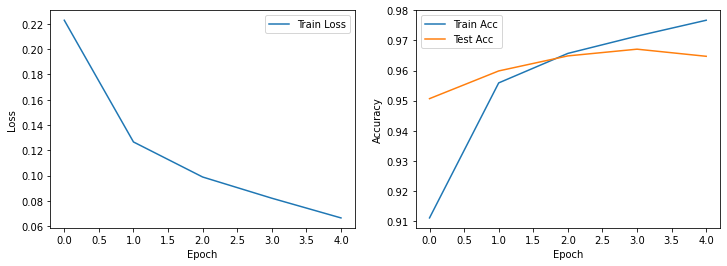

模型已保存。


In [6]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(test_accs, label='Test Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 保存模型
os.makedirs('./intermediate_data', exist_ok=True)
torch.save(model.state_dict(), './intermediate_data/bilstm_classifier.pt')
print("模型已保存。")

## 6. 总结与参考

- 双向 LSTM 结合注意力机制能有效处理变长序列，并获得不错的分类效果。
- 动态填充和 pack_padded_sequence 是提高训练效率的关键。

**参考资料**：
- [PyTorch LSTM 文档](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
- [Understanding LSTM Networks](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)